In [53]:
from astropy import units as u
from astropy.constants import G, c, M_jup
import numpy as np
from numpy import pi
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from math import gamma as Gamma
from scipy.integrate import quad
import sys
import os


## Implementation

$$\langle \Delta v_{\parallel} \rangle = -16\pi^2G^2(m_f+m)m_f\ln\Lambda F_2(v)$$
$$\langle \Delta v^2_{\parallel} \rangle = \frac{32\pi^2}{3}G^2m_f^2\ln\Lambda[F_4(v)+E_1(v)]v$$
$$\langle \Delta v^2_{\perp} \rangle = \frac{32\pi^2}{3}G^2m_f^2\ln\Lambda[3F_2(v)-F_4(v)+2E_1(v)]v$$

$$E_n(v)=\int_v^\infty\left(\frac{v_f}{v}\right)^nf(v_f)dv_f$$
$$F_n(v)=\int_0^v\left(\frac{v_f}{v}\right)^nf(v_f)dv_f$$

$$f(E) = \frac{3 - \gamma}{8} \sqrt{\frac{2}{\pi^{5}}} \frac{\Gamma(\gamma + 1)}{\Gamma(\gamma - 1/2)} \frac{M_\bullet}{m_\star} \frac{\phi_0^{3/2}}{(GM_\bullet)^3} \left( \frac{|E|}{\phi_0} \right)^{\gamma - 3/2}$$

$$r_{\mathrm{inf}} = r_m = 1\mathrm{pc}\left(\frac{M_{\bullet}}{10^6 * M_{\odot}}\right)^{1/2}$$
$$\gamma=7/4\tag{Bahcall-Wolf}$$

In [54]:
gamma_bw = 7/4 
M_exp = 7
M = 10**(M_exp) * u.Msun 
mf = 0.3 * u.Msun 
r_inf = 1* u.pc * (M / 1e6 / u.Msun) ** (0.5)
n_inf = (3-gamma_bw)*M / (4*pi*mf * r_inf**3)


In [55]:
def f(r,v):
    """? Distribution function in terms of r, v. Merritt 3.49"""
    phi0 = G*M / r_inf
    Energy = (G*M)/r - 0.5*v**2
    Af = (3-gamma_bw)/8 * np.sqrt(2)/np.sqrt(pi**5)  * (Gamma(gamma_bw+1) / Gamma(gamma_bw - 1/2)) * (M/mf) * (phi0**(3/2) / (G*M)**3)
    return Af * (np.abs(Energy)/phi0)**(gamma_bw-3/2)

def _standard_integrand_EF(r, vf, v, n):
    """Private helper method for functions E and F"""
    return (vf/v)**n * f(r, vf)

def E(n, v, r):
    """ 'Standard' form integral used in diffusion coefficient calculation. Merritt 5.56a"""
    vu = v.unit
    v_esc = np.sqrt(2*G*M/r).to(vu).value
    gu = _standard_integrand_EF(r, v, v, n).decompose().unit
    result, _ = quad(lambda vf: _standard_integrand_EF(r, vf*vu, v, n).to_value(gu), v.to_value(vu), v_esc)
    return result * gu * vu

def F(n, v, r):
    """ 'Standard' form integral used in diffusion coefficient calculation. Merritt 5.56b"""
    vu = v.unit
    gu = _standard_integrand_EF(r, v, v, n).decompose().unit
    result, _ = quad(lambda vf: _standard_integrand_EF(r, vf*vu, v, n).to_value(gu), 0, v.to_value(vu))
    return result * gu * vu

def sigma2(r):
    """1D velocity dispersion of stars in the NSC"""
    return G * M / (r * (1+gamma_bw))

### Coulomb logarithm
$$\sigma^2(r)=\frac{GM}{r(1+\gamma)}$$
$$b_{max}=\frac{n(r)}{dn/dr}=r/\gamma \tag{from Merritt 3.48}$$
$$b_{min} = \frac{G(m+m_f)}{\sigma^2(r)} = \frac{(m+m_f)(1+\gamma)}{M}\,r \tag{*}$$
$$\frac{b_{max}}{b_{min}} = \frac{M}{\gamma(1+\gamma)(m+m_f)} \quad \text{(r-independent!)}$$
$$\ln\Lambda = \ln\left(\frac{b_{max}}{b_{min}}\right)$$
*possibly missing a factor of 1/3 to match the Chandrasekhar convention?

In [56]:
def lnLambda(r, m):
    """Coulomb logaritm ?Maybe Chandrasekhar?"""
    b_max = r/gamma_bw #n(r)/(dn/dr) using equation 3.48 in Merritt
    b_min = G * (m+mf) / sigma2(r) #! possibly missing a factor of 1/3 to match the Chandrasekhar convention?
    return np.log(b_max/b_min)

def lnLambda_approx(r, m):
    return np.log(M/mf)

def lnLambda_approx_2(r, m):
    return np.log(M/m)

In [57]:
#Diffusion Coefficients — source?
def DC_1par(r, v, m):
    """1st order parallel diffusion coefficient. Corresponds to dynamical friction."""
    return -16 * pi**2 * G**2 * (mf + m) * mf * lnLambda(r,m) * F(2, v, r)

def DC_2par(r, v, m):
    """2nd order parallel diffusion coefficient."""
    const = 32 * pi**2 * G**2 * mf**2 / 3 
    return const * lnLambda(r,m) * (F(4, v, r) + E(1, v, r)) * v 

def DC_2perp(r, v, m):
    """2nd order perpendicular diffusion coefficient."""
    const = 32 * pi**2 * G**2 * mf**2 / 3
    return const * lnLambda(r,m) * (3*F(2, v, r) - F(4, v, r) + 2*E(1, v, r)) * v

In [58]:
def DC_2par_approx(r, v, m):
    """2nd order parallel diffusion coefficient using approximate Coulomb logarithm."""
    const = 32 * pi**2 * G**2 * mf**2 / 3
    return const * lnLambda_approx(r, m) * (F(4, v, r) + E(1, v, r)) * v

def DC_2perp_approx(r, v, m):
    """2nd order perpendicular diffusion coefficient using approximate Coulomb logarithm."""
    const = 32 * pi**2 * G**2 * mf**2 / 3
    return const * lnLambda_approx(r, m) * (3*F(2, v, r) - F(4, v, r) + 2*E(1, v, r)) * v

In [59]:
#========RELAXATION TIME==============
#! notes say to fix $v=\sqrt{\frac{GM_{\bullet}}{r}}$ for validation plots
#! I added a negative sign to the Dynamical Friction relaxation time because otherwise it is negative, and that did not make sense to me.
#! more common form would add a factor of 1/3 somewhere, but we are choosing to ignore that


def t_rel_DF(r, v, m):
    """first order (dynamical friction) relaxation time"""
    dc = DC_1par(r, v, m)
    sigma = np.sqrt(sigma2(r))
    return -sigma/dc

def t_rel_2par(r, v, m):
    """parallel second order relaxation time"""
    dc = DC_2par(r, v, m)
    return sigma2(r)/dc

def t_rel_2perp(r, v, m):
    """perpdendicular second order relaxation time"""
    dc = DC_2perp(r, v, m)
    return sigma2(r)/dc

## Demonstration

Globally used parameters/Initial Conditions

In [60]:
m_test = 10 * u.Msun #todo this will eventually be the third dimension of user input
r_vals = np.linspace(0.01, 1, 100) * u.pc #100 values linspaced between 0 and 1 pc with astropy units attached

tr_df = []
tr_2par = []
tr_2perp = []

for r_i in r_vals:
    v_test = np.sqrt(G*M / r_i)
    tr_df_i = t_rel_DF(r_i, v_test, m_test).to(u.Gyr)
    tr_2par_i = t_rel_2par(r_i, v_test, m_test).to(u.Gyr)
    tr_2perp_i = t_rel_2perp(r_i, v_test, m_test).to(u.Gyr)

    tr_df.append(tr_df_i)
    tr_2par.append(tr_2par_i)
    tr_2perp.append(tr_2perp_i)

Check:

**Ansatz $t^{x}_{rel}\propto r^{\alpha_x}, \mathrm{where}\  \alpha_x > 0$**

It is expected that $\alpha_{\parallel}=\alpha_{\perp}=\alpha_{\mathrm{DF}}=\gamma-3/2$

In [61]:
# numerically calculate alpha
fits = {}
for label, tr in [("DF", tr_df), ("par", tr_2par), ("perp", tr_2perp)]:
    alpha, log_C = np.polyfit(np.log(r_vals.value), np.log([t.value for t in tr]), 1)
    fits[label] = (alpha, log_C)
    print(f"alpha_{label} = {alpha:.3f}")

alpha_DF = 0.250
alpha_par = 0.250
alpha_perp = 0.250


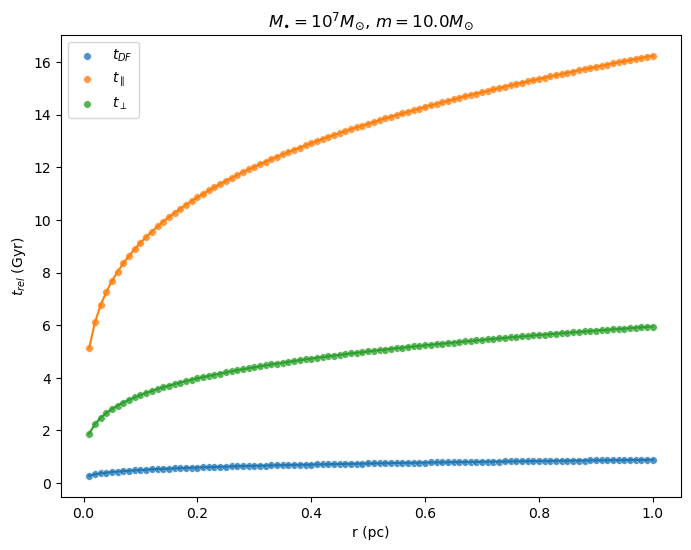

In [62]:
#plot each relaxation time t_rel(R) 

fig, ax = plt.subplots(figsize=(8,6))
ax.set_xlabel("r (pc)")
ax.set_ylabel(r"$t_{rel}$ (Gyr)")

r_pc = np.array([r.to(u.pc).value for r in r_vals])
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for i, (tr, label, key) in enumerate([(tr_df, r"$t_{DF}$", "DF"), (tr_2par, r"$t_{\parallel}$", "par"), (tr_2perp, r"$t_{\perp}$", "perp")]):
    alpha, log_C = fits[key]
    sns.scatterplot(x=r_pc, y=[t.to(u.Gyr).value for t in tr], ax=ax, label=label, color=colors[i], s=30, zorder=1, alpha=0.8)
    ax.plot(r_pc, np.exp(log_C) * r_pc**alpha, color=colors[i], linestyle='-', zorder=2)

ax.set_title(rf"$M_{{\bullet}}=10^{M_exp}M_{{\odot}}$, $m={m_test.value}M_{{\odot}}$")
ax.legend()
plt.show()

$$\delta \vec{v}_{discrete}^{i}=\langle\Delta v_{\parallel}\rangle \delta t \hat{v} + \sqrt{\langle\Delta v^2_{\parallel}\rangle \delta t} X_1 \hat{v}+ \sqrt{\langle\Delta v^2_{\perp}\rangle\delta t}X_2 (\cos\theta_2\hat{u}+\sin\theta_2\hat{w})$$

$$\frac{\delta \vec{v}_{discrete}^{i}}{\delta t}=\langle\Delta v_{\parallel}\rangle \hat{v} + \sqrt{\frac{\langle\Delta v^2_{\parallel}\rangle}{\delta t}} X_1 \hat{v}+ \sqrt{\frac{\langle\Delta v^2_{\perp}\rangle}{\delta t}}X_2 (\cos\theta_2\hat{u}+\sin\theta_2\hat{w})$$



$$a_{\hat v} = \langle\Delta v_{\parallel}\rangle + \sqrt{\frac{\langle\Delta v^2_{\parallel}\rangle}{\delta t}}\,X_1$$
$$a_{\hat u} = \sqrt{\frac{\langle\Delta v^2_{\perp}\rangle}{\delta t}}\,X_2\cos\theta_2$$
$$a_{\hat w} = \sqrt{\frac{\langle\Delta v^2_{\perp}\rangle}{\delta t}}\,X_2\sin\theta_2$$
with $X_1,X_2\sim\mathcal{N}(0,1)$.

In [63]:

X1, X2 = np.random.normal(0, 1, size=2) #Random numbers drawn from a gaussian mu=0, sigma=1
theta2 = np.random.uniform(0, 2*pi) #random drawn from a uniform distribution between 0, 2pi
#! maybe move these inside the dvdt function depending on what you're doing?

def dvdt(r, v, m, dt):
    """Discrete velocity kick per unit time, returned as components in the
    local frame (v_hat, u_hat, w_hat). Cell 8a8d154b."""
    dv_par   = DC_1par(r, v, m)   # <Delta v_par>
    dv2_par  = DC_2par(r, v, m)   # <Delta v^2_par>
    dv2_perp = DC_2perp(r, v, m)  # <Delta v^2_perp>

    v_comp = dv_par + np.sqrt(dv2_par / dt) * X1
    u_comp = np.sqrt(dv2_perp / dt) * X2 * np.cos(theta2)
    w_comp = np.sqrt(dv2_perp / dt) * X2 * np.sin(theta2)

    return u.Quantity([v_comp, u_comp, w_comp])

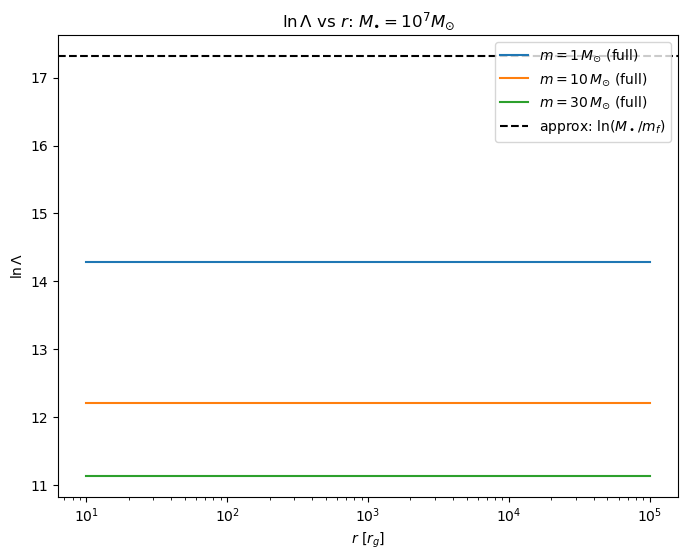

In [ ]:
r_g = (G * M / c**2).to(u.pc)
r_g_vals = np.geomspace(10, 1e5, 100)
r_arr_rg = r_g_vals * r_g

m_compare = [1, 10, 30] * u.Msun

fig, ax = plt.subplots(figsize=(2, 3))
ax.set_xlabel(r"$r\ [r_g]$")
ax.set_ylabel(r"$\ln\Lambda$")
ax.set_xscale('log')

for i, m_i in enumerate(m_compare):
    lnL_full = [float(lnLambda(r, m_i)) for r in r_arr_rg]
    ax.plot(r_g_vals, lnL_full, color=colors[i], label=rf"$m={m_i.value:.0f}\,M_{{\odot}}$ (full)")

lnL_approx = float(lnLambda_approx(r_arr_rg[0], m_compare[0]))
ax.axhline(lnL_approx, color='k', linestyle='--', label=r"approx: $\ln(M_\bullet/m_f)$")

ax.set_title(rf"$\ln\Lambda$ vs $r$: $M_{{\bullet}}=10^{{{M_exp}}}M_{{\odot}}$")
ax.legend()
plt.show()

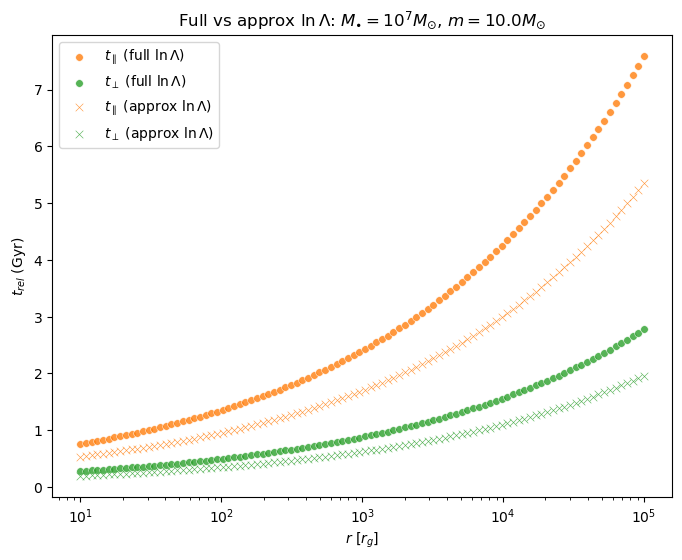

In [65]:
r_g = (G * M / c**2).to(u.pc)
r_g_vals = np.geomspace(10, 1e5, 100)
r_arr_rg = r_g_vals * r_g

tr_2par_rg     = []
tr_2perp_rg    = []
tr_2par_approx_rg  = []
tr_2perp_approx_rg = []

for r_i in r_arr_rg:
    v_i = np.sqrt(G * M / r_i)
    tr_2par_rg.append((sigma2(r_i) / DC_2par(r_i, v_i, m_test)).to(u.Gyr))
    tr_2perp_rg.append((sigma2(r_i) / DC_2perp(r_i, v_i, m_test)).to(u.Gyr))
    tr_2par_approx_rg.append((sigma2(r_i) / DC_2par_approx(r_i, v_i, m_test)).to(u.Gyr))
    tr_2perp_approx_rg.append((sigma2(r_i) / DC_2perp_approx(r_i, v_i, m_test)).to(u.Gyr))

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlabel(r"$r\ [r_g]$")
ax.set_ylabel(r"$t_{rel}$ (Gyr)")
ax.set_xscale('log')

sns.scatterplot(x=r_g_vals, y=[t.value for t in tr_2par_rg],         ax=ax, color=colors[1], s=30, zorder=1, alpha=0.8, label=r"$t_{\parallel}$ (full $\ln\Lambda$)")
sns.scatterplot(x=r_g_vals, y=[t.value for t in tr_2perp_rg],        ax=ax, color=colors[2], s=30, zorder=1, alpha=0.8, label=r"$t_{\perp}$ (full $\ln\Lambda$)")
sns.scatterplot(x=r_g_vals, y=[t.value for t in tr_2par_approx_rg],  ax=ax, color=colors[1], s=30, marker='x', zorder=2, alpha=0.8, label=r"$t_{\parallel}$ (approx $\ln\Lambda$)")
sns.scatterplot(x=r_g_vals, y=[t.value for t in tr_2perp_approx_rg], ax=ax, color=colors[2], s=30, marker='x', zorder=2, alpha=0.8, label=r"$t_{\perp}$ (approx $\ln\Lambda$)")

ax.set_title(rf"Full vs approx $\ln\Lambda$: $M_{{\bullet}}=10^{{{M_exp}}}M_{{\odot}}$, $m={m_test.value}M_{{\odot}}$")
ax.legend()
plt.show()